# Clustering K-medias — Ejercicio 1: separar los blobs y volver a elegir k

Copia de trabajo de `01 K-medias.ipynb`. Corre primero tal cual (blobs de
Geron, k=5, codo y silueta) y despues repite todo con los 5 centros
separados a ojo, sin cambiar `n_samples=2000` ni `random_state=7` en
`make_blobs`, ni el bucle `kmeans_per_k` (k=1..9, `random_state=42`).

In [1]:
import sys
assert sys.version_info >= (3, 5)
import sklearn
assert sklearn.__version__ >= "0.20"

import numpy as np
import os

np.random.seed(42)

import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

In [2]:
def plot_clusters(X, y=None):
    plt.scatter(X[:, 0], X[:, 1], c=y, s=1)
    plt.xlabel("$x_1$", fontsize=14)
    plt.ylabel("$x_2$", fontsize=14, rotation=0)

def plot_data(X):
    plt.plot(X[:, 0], X[:, 1], 'k.', markersize=2)

def plot_centroids(centroids, weights=None, circle_color='w', cross_color='k'):
    if weights is not None:
        centroids = centroids[weights > weights.max() / 10]
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='o', s=35, linewidths=8,
                color=circle_color, zorder=10, alpha=0.9)
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='x', s=2, linewidths=12,
                color=cross_color, zorder=11, alpha=1)

def plot_decision_boundaries(clusterer, X, resolution=1000, show_centroids=True,
                             show_xlabels=True, show_ylabels=True):
    mins = X.min(axis=0) - 0.1
    maxs = X.max(axis=0) + 0.1
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                         np.linspace(mins[1], maxs[1], resolution))
    Z = clusterer.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]), cmap="Pastel2")
    plt.contour(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]), linewidths=1, colors='k')
    plot_data(X)
    if show_centroids:
        plot_centroids(clusterer.cluster_centers_)
    if show_xlabels:
        plt.xlabel("$x_1$", fontsize=14)
    else:
        plt.tick_params(labelbottom=False)
    if show_ylabels:
        plt.ylabel("$x_2$", fontsize=14, rotation=0)
    else:
        plt.tick_params(labelleft=False)

def run_blob_experiment(blob_centers, blob_std, label):
    X, y = make_blobs(n_samples=2000, centers=blob_centers,
                       cluster_std=blob_std, random_state=7)

    plt.figure(figsize=(8, 4))
    plot_clusters(X)
    plt.title(f"Blobs ({label})")
    plt.show()

    kmeans = KMeans(n_clusters=5, random_state=42, init='k-means++', n_init='auto')
    kmeans.fit(X)

    plt.figure(figsize=(8, 4))
    plot_decision_boundaries(kmeans, X)
    plt.title(f"Voronoi k=5 ({label})")
    plt.show()

    kmeans_k3 = KMeans(n_clusters=3, random_state=42).fit(X)
    kmeans_k8 = KMeans(n_clusters=8, random_state=42).fit(X)
    print(f"[{label}] inertia k=3: {kmeans_k3.inertia_:.1f}")
    print(f"[{label}] inertia k=5: {kmeans.inertia_:.1f}")
    print(f"[{label}] inertia k=8: {kmeans_k8.inertia_:.1f}")

    kmeans_per_k = [KMeans(n_clusters=k, random_state=42).fit(X) for k in range(1, 10)]
    inertias = [model.inertia_ for model in kmeans_per_k]

    plt.figure(figsize=(8, 3.5))
    plt.plot(range(1, 10), inertias, "bo-")
    plt.xlabel("$k$", fontsize=14)
    plt.ylabel("Inertia", fontsize=14)
    plt.title(f"Codo ({label})")
    plt.show()
    print(f"[{label}] inertias k=1..9:", [round(v, 1) for v in inertias])

    silhouette_scores = [silhouette_score(X, model.labels_) for model in kmeans_per_k[1:]]
    best_k_silhouette = 2 + int(np.argmax(silhouette_scores))

    plt.figure(figsize=(8, 3))
    plt.plot(range(2, 10), silhouette_scores, "bo-")
    plt.xlabel("$k$", fontsize=14)
    plt.ylabel("Silhouette score", fontsize=14)
    plt.title(f"Silueta ({label})")
    plt.show()
    print(f"[{label}] silhouette scores k=2..9:", [round(v, 4) for v in silhouette_scores])
    print(f"[{label}] mejor k por silueta: {best_k_silhouette}")

    return X, kmeans_per_k, inertias, silhouette_scores

## 1. Corrida original (centros de Geron)

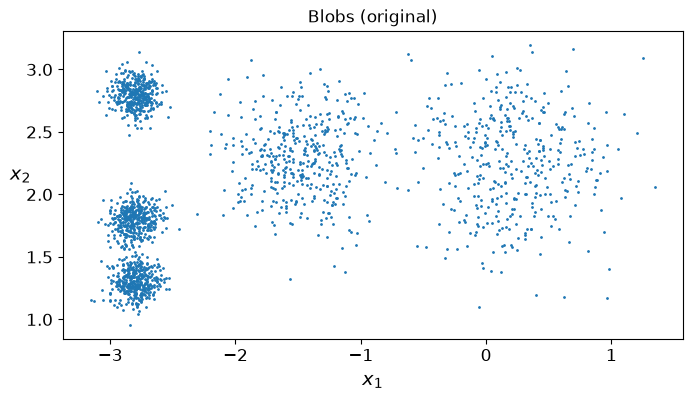

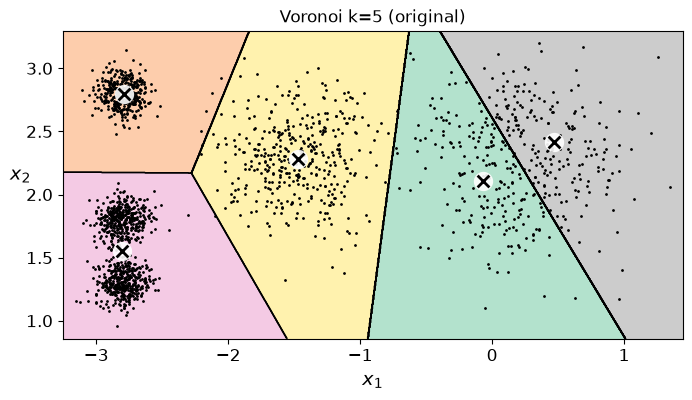

[original] inertia k=3: 653.2
[original] inertia k=5: 224.1
[original] inertia k=8: 127.1


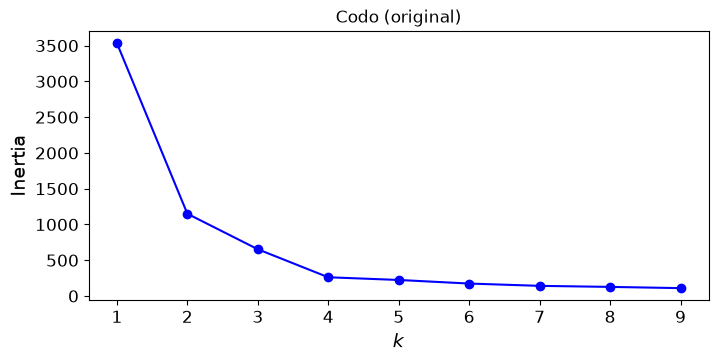

[original] inertias k=1..9: [3534.8, 1149.9, 653.2, 261.8, 224.1, 173.9, 141.8, 127.1, 109.9]


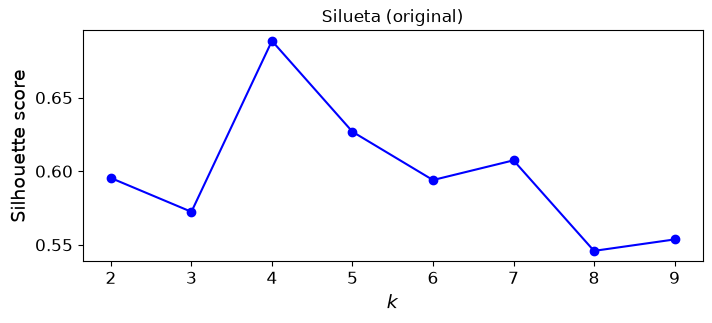

[original] silhouette scores k=2..9: [0.5954, 0.5724, 0.6885, 0.6268, 0.594, 0.6074, 0.5459, 0.5536]
[original] mejor k por silueta: 4


In [3]:
blob_centers = np.array(
    [[ 0.2,  2.3],
     [-1.5 ,  2.3],
     [-2.8,  1.8],
     [-2.8,  2.8],
     [-2.8,  1.3]])
blob_std = np.array([0.4, 0.3, 0.1, 0.1, 0.1])

X_orig, kmeans_per_k_orig, inertias_orig, sil_orig = run_blob_experiment(
    blob_centers, blob_std, "original"
)

## 2. Blobs separados

Los tres centros de la izquierda ya no comparten `x=-2.8`: se movieron a
posiciones bien distintas en x e y, sin cambiar `n_samples`, `random_state`
ni el resto de hiperparametros.

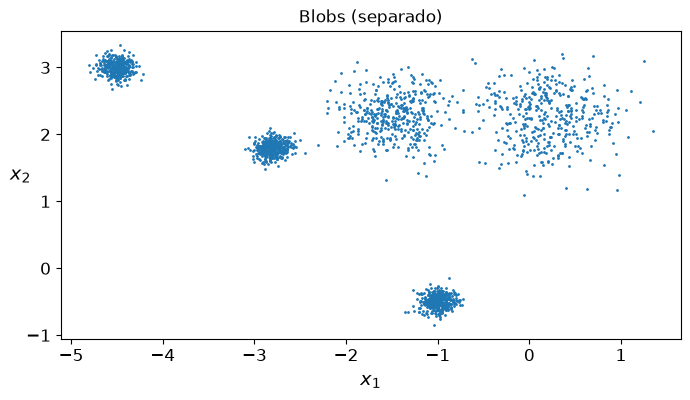

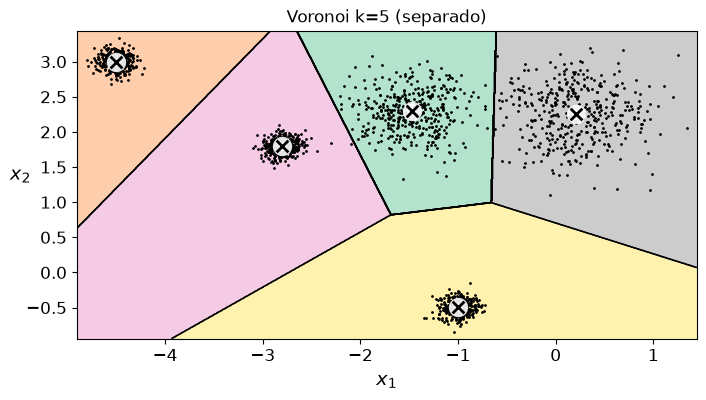

[separado] inertia k=3: 2412.1
[separado] inertia k=5: 212.6
[separado] inertia k=8: 119.4


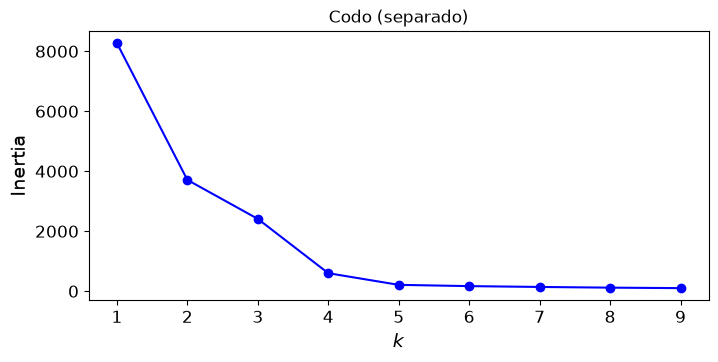

[separado] inertias k=1..9: [8272.7, 3711.6, 2412.1, 601.2, 212.6, 170.2, 142.4, 119.4, 103.0]


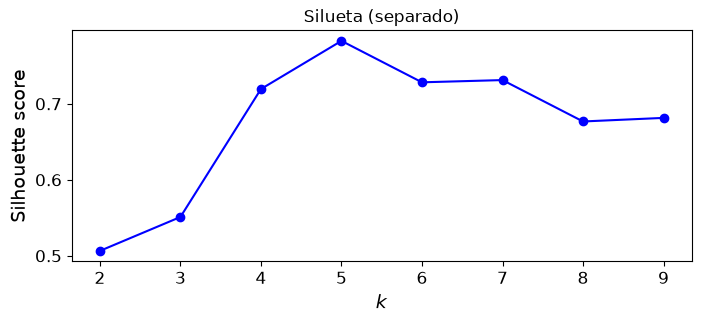

[separado] silhouette scores k=2..9: [0.5064, 0.551, 0.7194, 0.7828, 0.7283, 0.7312, 0.6768, 0.6815]
[separado] mejor k por silueta: 5


In [4]:
blob_centers_new = np.array(
    [[ 0.2,  2.3],
     [-1.5,  2.3],
     [-2.8,  1.8],
     [-4.5,  3.0],
     [-1.0, -0.5]])
blob_std_new = np.array([0.4, 0.3, 0.1, 0.1, 0.1])

X_new, kmeans_per_k_new, inertias_new, sil_new = run_blob_experiment(
    blob_centers_new, blob_std_new, "separado"
)

## 3. Comparación lado a lado

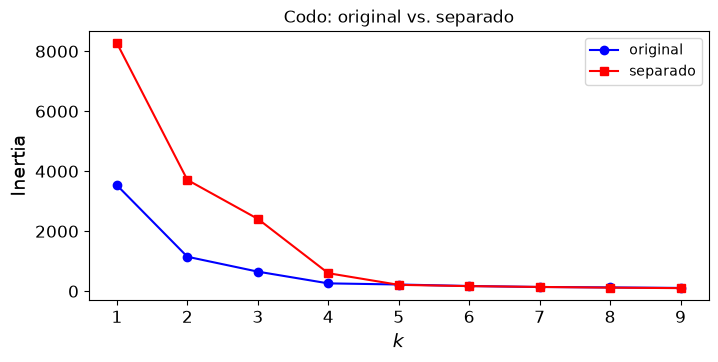

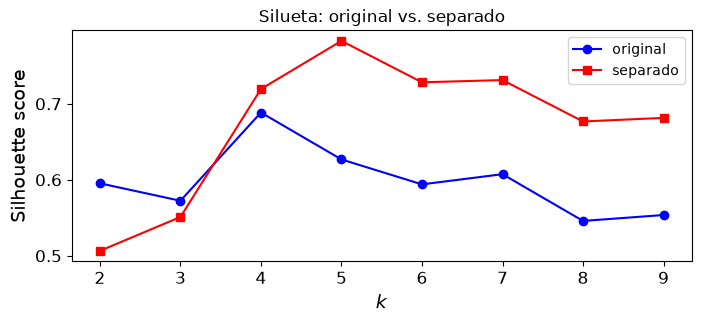

In [5]:
plt.figure(figsize=(8, 3.5))
plt.plot(range(1, 10), inertias_orig, "bo-", label="original")
plt.plot(range(1, 10), inertias_new, "rs-", label="separado")
plt.xlabel("$k$", fontsize=14)
plt.ylabel("Inertia", fontsize=14)
plt.legend()
plt.title("Codo: original vs. separado")
plt.show()

plt.figure(figsize=(8, 3))
plt.plot(range(2, 10), sil_orig, "bo-", label="original")
plt.plot(range(2, 10), sil_new, "rs-", label="separado")
plt.xlabel("$k$", fontsize=14)
plt.ylabel("Silhouette score", fontsize=14)
plt.legend()
plt.title("Silueta: original vs. separado")
plt.show()

## Reto opcional

### a) Mismos centros de Geron, solo subir `std` de 0.1 a 0.4

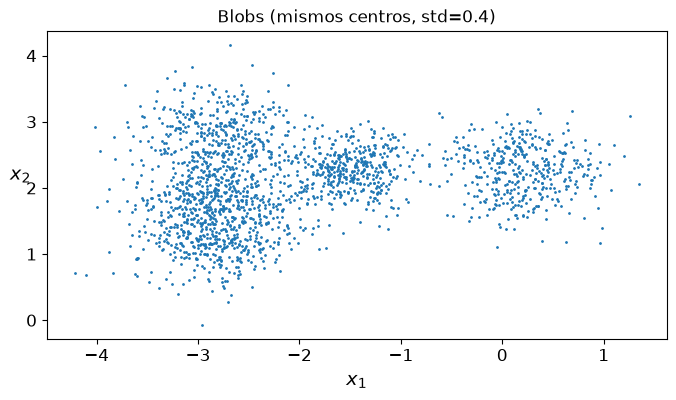

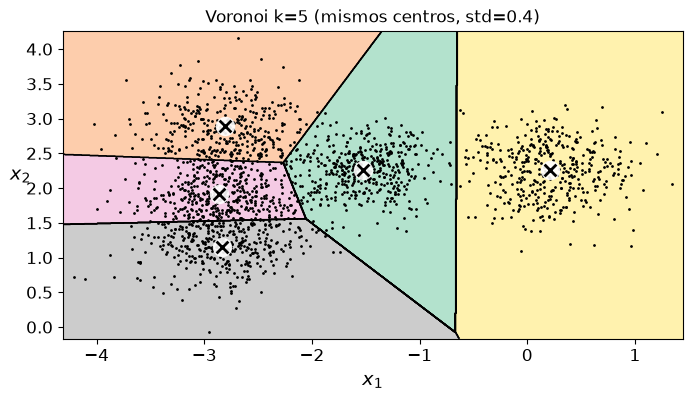

[mismos centros, std=0.4] inertia k=3: 941.9
[mismos centros, std=0.4] inertia k=5: 451.4
[mismos centros, std=0.4] inertia k=8: 329.2


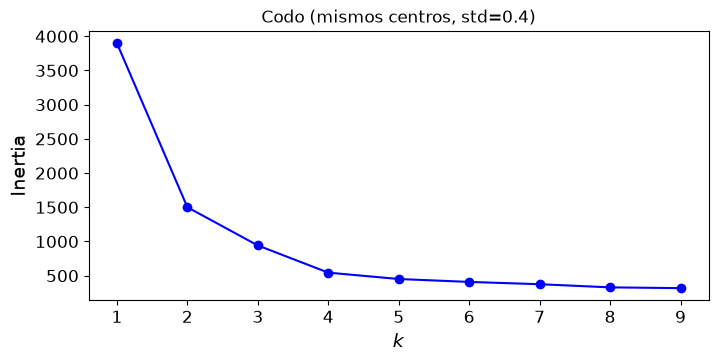

[mismos centros, std=0.4] inertias k=1..9: [3899.8, 1500.7, 941.9, 544.5, 451.4, 408.8, 375.3, 329.2, 317.9]


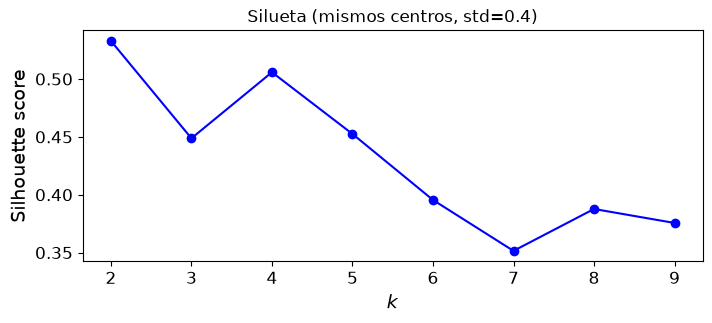

[mismos centros, std=0.4] silhouette scores k=2..9: [0.5329, 0.4487, 0.5058, 0.4525, 0.3955, 0.3515, 0.3877, 0.3756]
[mismos centros, std=0.4] mejor k por silueta: 2


In [6]:
blob_centers_std_only = blob_centers.copy()
blob_std_only = np.array([0.4, 0.3, 0.4, 0.4, 0.4])

X_std, kmeans_per_k_std, inertias_std, sil_std = run_blob_experiment(
    blob_centers_std_only, blob_std_only, "mismos centros, std=0.4"
)

### b) Segmentación de imagen con una foto propia (en vez de ladybug.png)

image shape: (400, 600, 3)


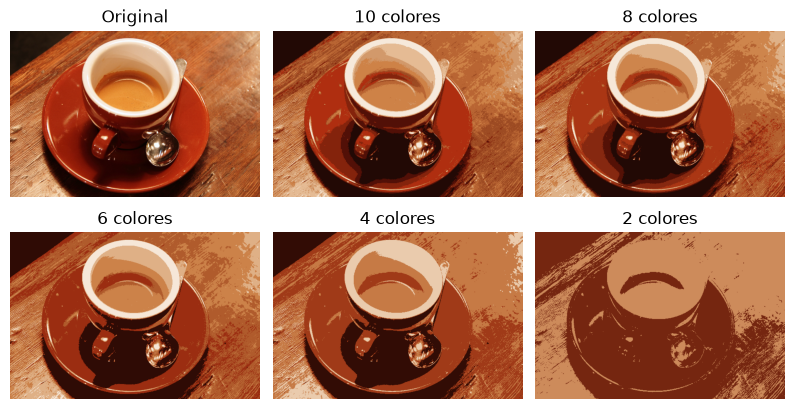

In [7]:
# Foto real distinta de ladybug.png: taza de cafe (dominio publico, imagen de
# muestra de scikit-image), con colores bien diferenciados para probar la
# segmentacion por color.
from skimage import data as skdata
image = skdata.coffee()
print("image shape:", image.shape)

X_img = image.reshape(-1, 3)
segmented_imgs = []
n_colors = (10, 8, 6, 4, 2)
for n_clusters in n_colors:
    km = KMeans(n_clusters=n_clusters, random_state=42, n_init='auto').fit(X_img)
    segmented_img = km.cluster_centers_[km.labels_]
    segmented_imgs.append(segmented_img.reshape(image.shape).astype('uint8'))

plt.figure(figsize=(10, 5))
plt.subplots_adjust(wspace=0.05, hspace=0.1)
plt.subplot(231)
plt.imshow(image)
plt.title("Original")
plt.axis('off')
for idx, n_clusters in enumerate(n_colors):
    plt.subplot(232 + idx)
    plt.imshow(segmented_imgs[idx])
    plt.title(f"{n_clusters} colores")
    plt.axis('off')
plt.show()

### c) Codo y silueta sobre Iris (4 atributos)

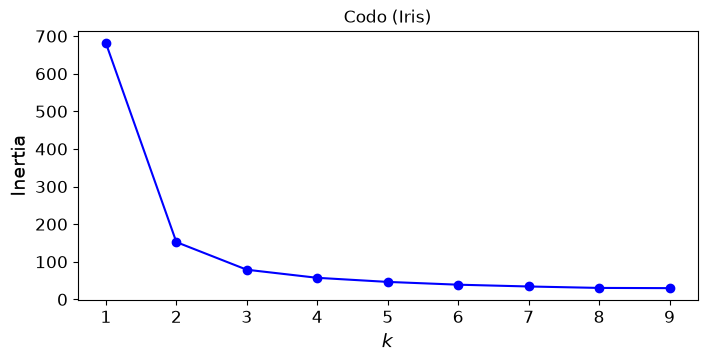

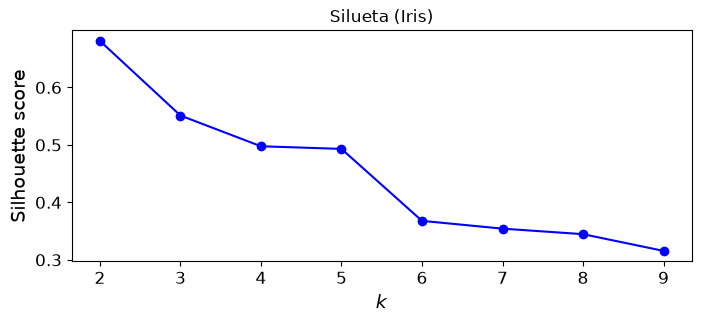

inertias Iris k=1..9: [681.37, 152.35, 78.86, 57.35, 46.47, 39.07, 34.31, 30.48, 29.91]
silhouette Iris k=2..9: [0.681, 0.5512, 0.4976, 0.4931, 0.3678, 0.3543, 0.3447, 0.3156]
mejor k por silueta (Iris): 2


In [8]:
from sklearn.datasets import load_iris

iris = load_iris()
X_iris = iris.data

kmeans_per_k_iris = [KMeans(n_clusters=k, random_state=42, n_init='auto').fit(X_iris)
                     for k in range(1, 10)]
inertias_iris = [m.inertia_ for m in kmeans_per_k_iris]
sil_iris = [silhouette_score(X_iris, m.labels_) for m in kmeans_per_k_iris[1:]]
best_k_iris = 2 + int(np.argmax(sil_iris))

plt.figure(figsize=(8, 3.5))
plt.plot(range(1, 10), inertias_iris, "bo-")
plt.xlabel("$k$", fontsize=14)
plt.ylabel("Inertia", fontsize=14)
plt.title("Codo (Iris)")
plt.show()

plt.figure(figsize=(8, 3))
plt.plot(range(2, 10), sil_iris, "bo-")
plt.xlabel("$k$", fontsize=14)
plt.ylabel("Silhouette score", fontsize=14)
plt.title("Silueta (Iris)")
plt.show()

print("inertias Iris k=1..9:", [round(v, 2) for v in inertias_iris])
print("silhouette Iris k=2..9:", [round(v, 4) for v in sil_iris])
print("mejor k por silueta (Iris):", best_k_iris)